<a href="https://www.kaggle.com/code/maximendacleu/youtube-video-analytics?scriptVersionId=335570975" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 📊 YouTube Content Performance - EDA & ML

The objective of this notebook is to transform raw YouTube video metadata into actionable insight for content strategy, 
audience engagement, and category-level investment decisions.

***Core we will answer:***
- Which content categories drive the most reach and engagement?
- What is the relationship between video duration and performance?
- Are "shorts" outperforming long-form content? By how much?
- Which channels dominate their niche?
- How does video age affect accumulated views?
- What engagement patterns separate viral from average content?
- Where should a content creator / sponsor invest next?

## 1. Environment setup

In [1]:
import warnings, json, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
PALETTE = sns.color_palette("viridis", n_colors=12)
print("✅ Environment ready.")

✅ Environment ready.


In [2]:
RAW_PATH = "/kaggle/input/youtube-analytics-data/youtube_recommendation_dataset -.csv"

df = pd.read_csv(RAW_PATH)

# Standardize column names
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(" ", "_"))

print(f"Shape: {df.shape}")
df.head(3)

Shape: (537, 16)


,title,channel_title,published_at,category_id,view_count,like_count,comment_count,favorite_count,duration,definition,caption,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,AlofokeMusicSounds,2025-11-16 15:34:55+00:00,10,1405647,140463,9063,0,PT1M51S,hd,False,0.1064,0.0999,0.0064,111,1
1,Moana | Official Teaser,Disney,2025-11-17 17:00:47+00:00,24,2776847,26801,6684,0,PT1M,hd,True,0.0121,0.0097,0.0024,60,0
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,CaylusBlox,2025-11-17 22:57:14+00:00,20,1189857,16174,1827,0,PT18M2S,hd,False,0.0151,0.0136,0.0015,1082,0


In [3]:
# Coerce data types
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df["category_id"]  = df["category_id"].astype("category")
df["definition"]   = df["definition"].astype("category")
df["caption"]      = df["caption"].astype(str).str.upper().map({"TRUE": True, "FALSE": False})

# YouTube category mapping (based on standard YouTube category IDs)
CATEGORY_MAP = {
    1:  "Film & Animation",
    2:  "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    17: "Sports",
    19: "Travel & Events",
    20: "Gaming",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "Howto & Style",
    27: "Education",
    28: "Science & Tech",
    29: "Nonprofits & Activism",
    30: "Movies",
}
df["category_name"] = df["category_id"].astype(int).map(CATEGORY_MAP)

print(df.dtypes)
df[["title", "category_name", "view_count", "engagement_rate"]].head()

title                                   object
channel_title                           object
published_at               datetime64[ns, UTC]
category_id                           category
view_count                               int64
like_count                               int64
comment_count                            int64
favorite_count                           int64
duration                                object
definition                            category
caption                                   bool
engagement_rate                        float64
likes_to_views_ratio                   float64
comments_to_views_ratio                float64
duration_seconds                         int64
video_age_days                           int64
category_name                           object
dtype: object


,title,category_name,view_count,engagement_rate
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,Music,1405647,0.1064
1,Moana | Official Teaser,Entertainment,2776847,0.0121
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,Gaming,1189857,0.0151
3,ALLDAY PROJECT - ‘ONE MORE TIME’ M/V,Music,5319161,0.0024
4,La Lupa | Vendetta Hero Trailer | Overwatch 2,Gaming,597542,0.0778


## 2. Data quality assessment

Before any analysis we audit:
- Missing values (and their business meaning)
- Duplicate rows (same title + channel + publish time)
- Implausible values (e.g., views = 0, likes > views)
- Type integrity

In [4]:
def quality_report(d: pd.DataFrame) -> pd.DataFrame:
    return (pd.DataFrame({
        "dtype":        d.dtypes.astype(str),
        "n_missing":    d.isna().sum(),
        "pct_missing":  d.isna().mean() * 100,
        "n_unique":     d.nunique(dropna=False),
        "n_zeros":     (d == 0).sum() if d.select_dtypes("number").shape[1] else 0,
    }))

qa = quality_report(df)
qa

,dtype,n_missing,pct_missing,n_unique,n_zeros
title,object,0,0.0000,533,0
channel_title,object,0,0.0000,344,0
published_at,"datetime64[ns, UTC]",0,0.0000,537,0
category_id,category,0,0.0000,12,0
view_count,int64,0,0.0000,537,1
like_count,int64,0,0.0000,525,12
comment_count,int64,0,0.0000,513,6
favorite_count,int64,0,0.0000,1,537
duration,object,0,0.0000,366,0
definition,category,0,0.0000,2,0


In [5]:
n_dupes = df.duplicated(subset=["title", "channel_title", "published_at"]).sum()
print(f"Duplicates (title+channel+published_at): {n_dupes}")

# Logical consistency
inconsistent = df[(df["like_count"] > df["view_count"]) |
                  (df["comment_count"] > df["view_count"])]
print(f"Rows where likes/comments > views: {len(inconsistent)}")

# Videos with 0 views (likely private/removed)
zero_views = df[df["view_count"] == 0]
print(f"Zero-view videos: {len(zero_views)}")
zero_views[["title", "channel_title", "view_count", "video_age_days"]]

Duplicates (title+channel+published_at): 0
Rows where likes/comments > views: 0
Zero-view videos: 1


,title,channel_title,view_count,video_age_days
32,World at War,World at War,0,15


In [6]:
df = df.drop(columns=["favorite_count"])

## 3. Feature engineering

We add relevant derived metrics:

| Feature | Formula | Rationale |
|---|---|---|
| `format` | "Short" if duration ≤ 60s, "Mid" if ≤ 600s, "Long" otherwise | YouTube Shorts vs long-form |
| `views_per_day` | view_count / max(video_age_days, 1) | Velocity - neutralizes age bias |
| `likes_per_comment` | like_count / max(comment_count,1) | Passive vs active engagement |
| `engagement_bucket` | Q-cut on engagement_rate | Segmentation |
| `viral_flag` | view_count > p95 AND engagement_rate > median | True virality |
| `publish_hour_utc` | hour of publish time | Posting schedule |
| `publish_dow` | day of week | Posting schedule |
| `publish_year` | year | Cohort analysis |

In [7]:
def classify_format(sec):
    if sec <= 60:   return "Short (≤60s)"
    if sec <= 600:  return "Mid (1–10 min)"
    return "Long (>10 min)"

df["format"]              = df["duration_seconds"].apply(classify_format)
df["views_per_day"]       = df["view_count"] / df["video_age_days"].clip(lower=1)
df["likes_per_comment"]   = df["like_count"] / df["comment_count"].clip(lower=1)
df["publish_hour_utc"]    = df["published_at"].dt.hour
df["publish_dow"]         = df["published_at"].dt.day_name()
df["publish_year"]        = df["published_at"].dt.year
df["publish_month"]       = df["published_at"].dt.to_period("M").astype(str)

# Engagement bucket via quantile
df["engagement_bucket"] = pd.qcut(df["engagement_rate"], q=4,
                                  labels=["Low","Mid","High","Very High"])

# Viral flag
v95 = df["view_count"].quantile(0.95)
med_eng = df["engagement_rate"].median()
df["viral_flag"] = (df["view_count"] > v95) & (df["engagement_rate"] > med_eng)

df[["title","format","views_per_day","engagement_bucket","viral_flag"]].head()

,title,format,views_per_day,engagement_bucket,viral_flag
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,Mid (1–10 min),"1,405,647.0000",Very High,False
1,Moana | Official Teaser,Short (≤60s),"2,776,847.0000",Low,False
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,Long (>10 min),"1,189,857.0000",Low,False
3,ALLDAY PROJECT - ‘ONE MORE TIME’ M/V,Mid (1–10 min),"5,319,161.0000",Low,False
4,La Lupa | Vendetta Hero Trailer | Overwatch 2,Mid (1–10 min),"597,542.0000",Very High,False


## 4. Univariate profiling

We examine distributions of the four core KPIs: views, likes, comments, engagement_rate.
Web/YouTube data are typically **power-law distributed**. A log scale will be used for readability.

In [8]:
KPI = ["view_count","like_count","comment_count","engagement_rate",
       "likes_to_views_ratio","comments_to_views_ratio","duration_seconds"]

df[KPI].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
view_count,537.0000,"21,457,518.1825","40,151,999.7352",0.0000,"1,219,859.4000","2,676,921.0000","6,385,911.0000","22,706,041.0000","57,791,535.4000","85,943,839.6000","198,851,629.4000","369,731,024.0000"
like_count,537.0000,"433,604.3892","838,671.0516",0.0000,"14,026.8000","55,591.0000","155,055.0000","463,189.0000","1,059,406.8000","1,816,400.8000","3,720,119.6400","10,879,340.0000"
comment_count,537.0000,"7,125.7002","36,075.1150",0.0000,327.0000,"1,018.0000","2,354.0000","5,925.0000","14,835.2000","23,997.8000","44,382.6000","810,641.0000"
engagement_rate,537.0000,0.0287,0.0206,0.0000,0.0082,0.0156,0.0244,0.0374,0.0535,0.0664,0.0981,0.2157
likes_to_views_ratio,537.0000,0.0277,0.0197,0.0000,0.0082,0.0153,0.0236,0.0363,0.0512,0.0647,0.0940,0.1991
comments_to_views_ratio,537.0000,0.0010,0.0022,0.0000,0.0000,0.0001,0.0004,0.0010,0.0024,0.0042,0.0099,0.0260
duration_seconds,537.0000,"4,802.7467","13,748.2494",0.0000,27.6000,52.0000,390.0000,"1,639.0000","14,245.0000","36,783.8000","77,783.1200","105,227.0000"


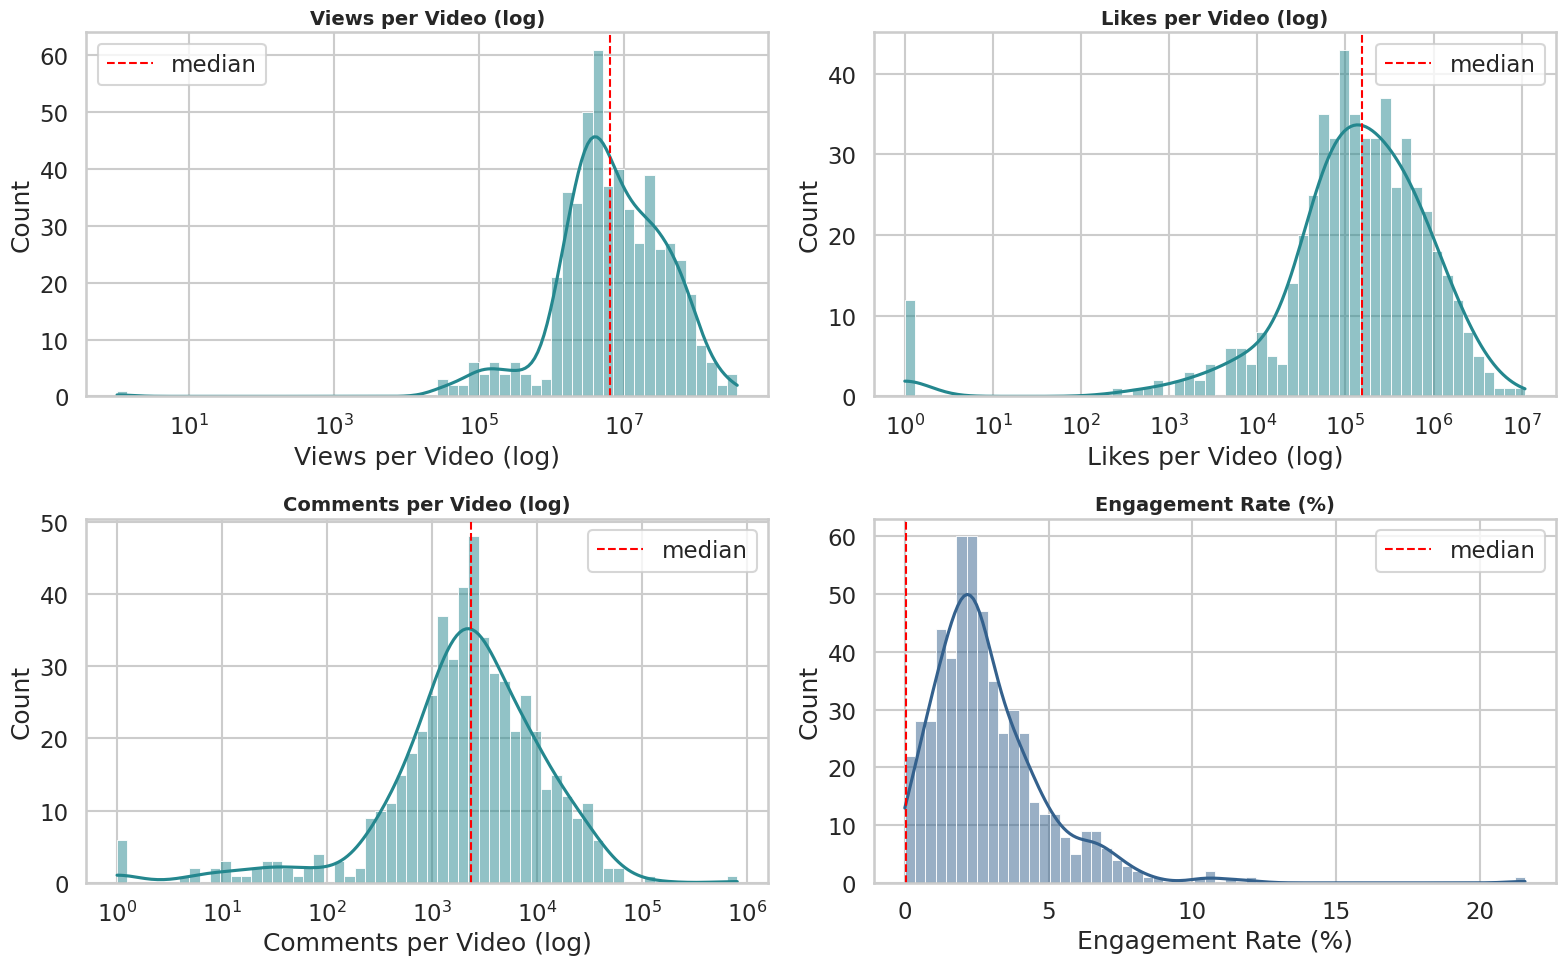

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
targets = [
    ("view_count",        "Views per Video (log)"),
    ("like_count",        "Likes per Video (log)"),
    ("comment_count",     "Comments per Video (log)"),
    ("engagement_rate",   "Engagement Rate (%)"),
]
for ax, (col, title) in zip(axes.flatten(), targets):
    if col == "engagement_rate":
        sns.histplot(df[col]*100, bins=60, kde=True, ax=ax, color=PALETTE[3])
        ax.set_xlabel("Engagement Rate (%)")
    else:
        sns.histplot(df[col].clip(lower=1), bins=60, kde=True, log_scale=True,
                     ax=ax, color=PALETTE[5])
        ax.set_xlabel(title)
    ax.set_title(title)
    ax.axvline(df[col].median(), color="red", ls="--", lw=1.5, label="median")
    ax.legend()
plt.tight_layout(); plt.show()

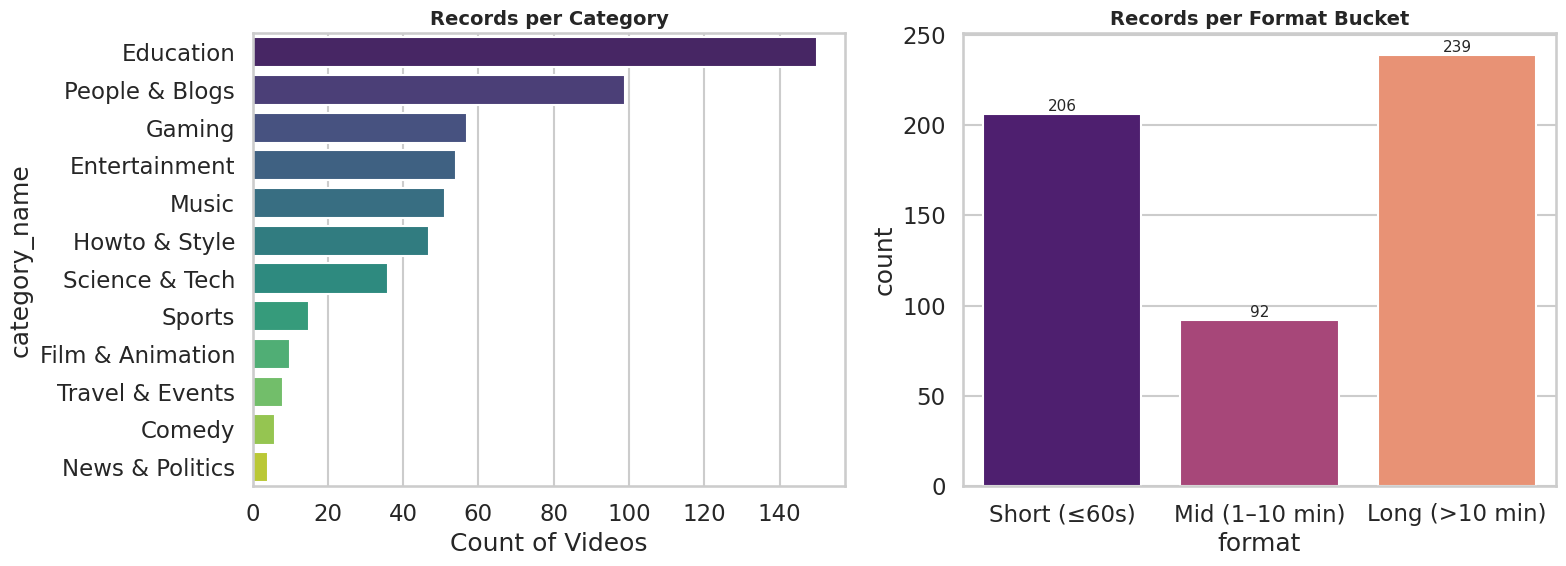

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_order = df["category_name"].value_counts().index
sns.countplot(y=df["category_name"], order=cat_order, ax=axes[0], palette="viridis")
axes[0].set_title("Records per Category")
axes[0].set_xlabel("Count of Videos")

fmt_order = ["Short (≤60s)","Mid (1–10 min)","Long (>10 min)"]
sns.countplot(x=df["format"], order=fmt_order, ax=axes[1], palette="magma")
axes[1].set_title("Records per Format Bucket")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)
plt.tight_layout(); plt.show()

***Interpretation:***

- The dataset is dominated by **Education**, **People & Blogs**, **Gaming**, **Entertainment** and **Music**. Together these 5 categories account for the majority of rows.
- Shorts (≤60s) are the most frequent format, reflecting YouTube's algorithmic push toward short-form content in 2024–2025.
- The view distribution is **scale-free**, a small number of videos drive the majority of total views. This is consistent with the classic Pareto / 80-20 pattern of UGC platforms.

## 5. Bivariate & Multivariate Analysis

We now examine how KPIs co-vary.

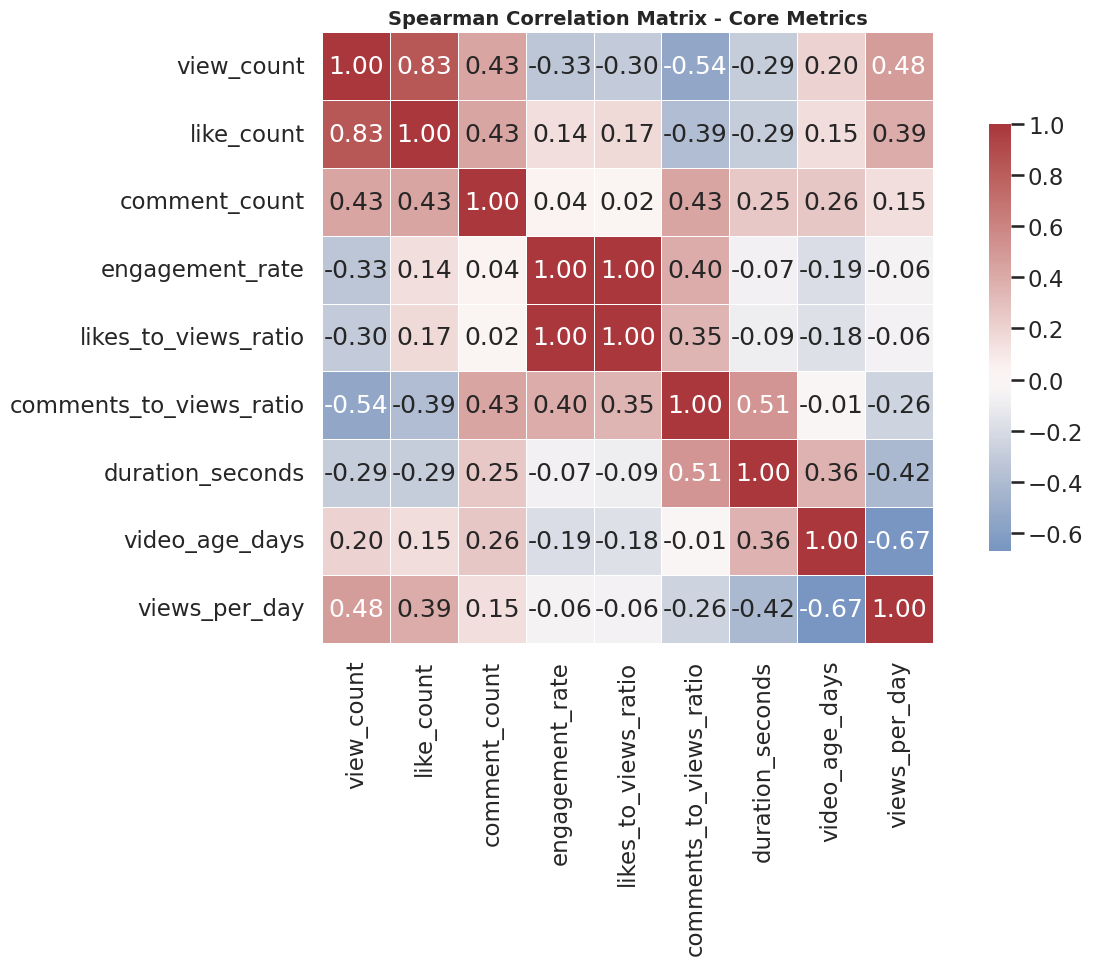

In [11]:
num_cols = ["view_count","like_count","comment_count",
            "engagement_rate","likes_to_views_ratio",
            "comments_to_views_ratio","duration_seconds",
            "video_age_days","views_per_day"]

corr = df[num_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag",
            center=0, square=True, linewidths=.5, cbar_kws={"shrink":.7})
plt.title("Spearman Correlation Matrix - Core Metrics")
plt.tight_layout(); plt.show()

***Interpretation:***

- `view_count` ↔ `like_count` (0.83) and `view_count` ↔ `comment_count` (0.43) are strongly positive. Reach drives absolute engagement.
- `view_count` ↔ `engagement_rate` is **negative** (-0.33). As a video reaches beyond its core fandom, the average viewer is less invested and engages at a lower rate.
- `duration_seconds` shows a **negative correlation** with `engagement_rate` (-0.07) and `view_count` (-0.29). This means that long videos don't automatically win.
- `video_age_days` (older videos) is positively correlated with `view_count` (0.20)  but **negatively** with `views_per_day` (-0.67), suggesting the velocity metric successfully normalizes for age.
- `likes_to_views_ratio` and `comments_to_views_ratio` are positively correlated (0.35). Likes and comments measure different engagement intents (passive approval vs. active discussion).

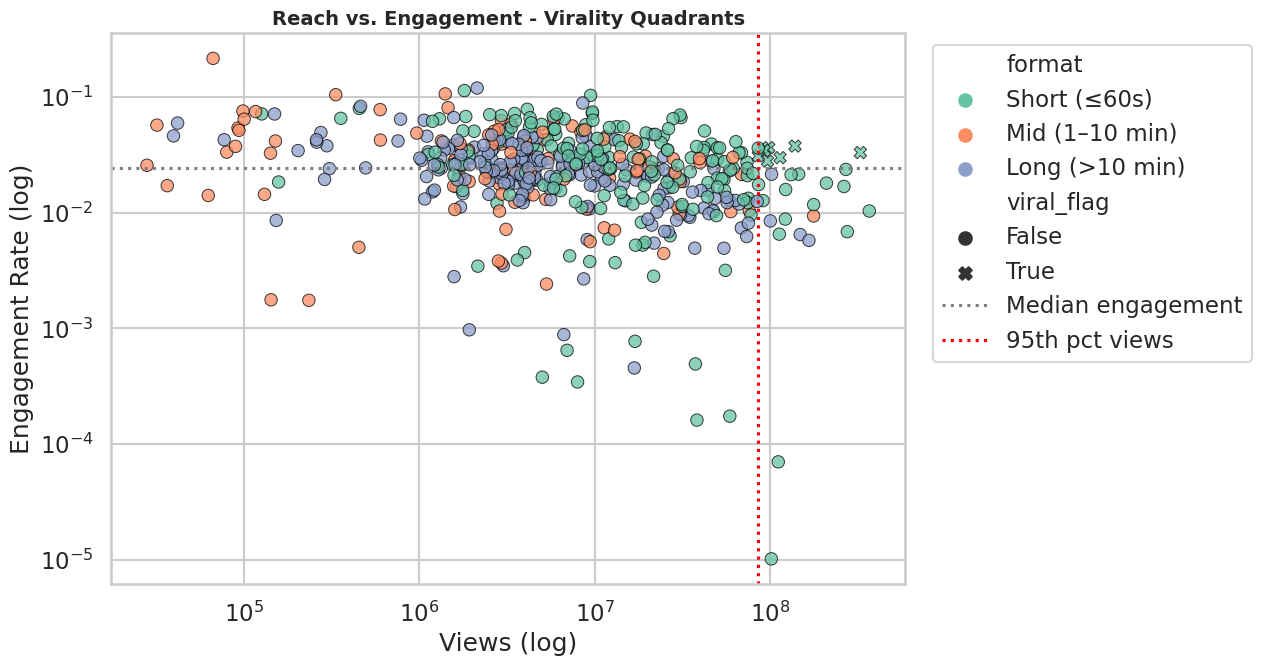

In [12]:
plt.figure(figsize=(13, 7))
sns.scatterplot(
    data=df, x="view_count", y="engagement_rate",
    hue="format", style="viral_flag",
    hue_order=fmt_order, palette="Set2", alpha=.75, s=80, edgecolor="black", lw=.3
)
plt.xscale("log"); plt.yscale("log")
plt.axhline(df["engagement_rate"].median(), color="grey", ls=":", label="Median engagement")
plt.axvline(df["view_count"].quantile(.95), color="red", ls=":", label="95th pct views")
plt.title("Reach vs. Engagement - Virality Quadrants")
plt.xlabel("Views (log)"); plt.ylabel("Engagement Rate (log)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

***Interpretation:***
- **Quadrant I (top-right)** - *True Virals*: high reach and high engagement.
- **Quadrant II (top-left)** - *Community Hits*: low reach, high engagement.
- **Quadrant III (bottom-left)** - *Long Tail*: low reach, low engagement.
- **Quadrant IV (bottom-right)** - *Mass Reach, Low Bonding*: broad casual audience.

Shorts tend to populate Quadrants II and IV (high variance in engagement), while long-form educational content sits mostly in Quadrant III with a few outliers in Quadrant I.

## 6. Category Deep-Dive

For each category we compute:
- Median views & engagement
- Total accumulated views (category power)
- Format mix
- Viral share

This reveals **where the audience attention actually lives** versus where individual creators thrive.

In [13]:
cat_agg = (df.groupby("category_name", observed=True)
             .agg(records=("title","count"),
                  median_views=("view_count","median"),
                  total_views=("view_count","sum"),
                  median_engagement=("engagement_rate","median"),
                  median_duration=("duration_seconds","median"),
                  viral_share=("viral_flag","mean"))
             .sort_values("total_views", ascending=False)
             .reset_index())
cat_agg["viral_share"] = (cat_agg["viral_share"]*100).round(1)
cat_agg

,category_name,records,median_views,total_views,median_engagement,median_duration,viral_share
0,People & Blogs,99,"22,752,407.0000",3903414037,0.0234,57.0000,3.0000
1,Howto & Style,47,"44,417,159.0000",2479319735,0.0129,543.0000,4.3000
2,Entertainment,54,"9,614,176.5000",1288240540,0.0296,107.0000,1.9000
3,Education,150,"3,950,826.0000",937603557,0.0246,"1,791.0000",0.0000
4,Music,51,"3,694,754.0000",862209047,0.0360,185.0000,0.0000
5,Sports,15,"28,022,468.0000",822758038,0.0123,866.0000,6.7000
6,Gaming,57,"2,371,910.0000",412279369,0.0208,684.0000,0.0000
7,Film & Animation,10,"7,689,018.0000",311171272,0.0280,318.5000,0.0000
8,Science & Tech,36,"3,181,562.0000",224771559,0.0274,709.5000,0.0000
9,Travel & Events,8,"13,004,411.5000",146244379,0.0166,58.0000,0.0000


In [14]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Total Views by Category",
                                                    "Median Engagement Rate by Category"),
                    horizontal_spacing=0.18)

fig.add_trace(go.Bar(x=cat_agg["total_views"], y=cat_agg["category_name"],
                     orientation="h", marker_color=px.colors.sequential.Viridis,
                     name="Total Views"), row=1, col=1)
fig.add_trace(go.Bar(x=cat_agg["median_engagement"]*100, y=cat_agg["category_name"],
                     orientation="h", marker_color=px.colors.sequential.Magma,
                     name="Median Engagement %"), row=1, col=2)
fig.update_yaxes(autorange="reversed")
fig.update_layout(height=600, width=1300, showlegend=False,
                  title_text="Category Performance - Reach vs Engagement")
fig.show()

***Interpretation:***
- **People & Blogs, Howto & Style**, and **Entertainment** lead in **total accumulated views**, driven by short-form viral content.
- **Music** videos show the **highest median engagement rate** (3.60), refering to strong fandom behavior.

## 7. Format / Duration Analysis

In [15]:
fmt_agg = (df.groupby("format")
             .agg(records=("title","count"),
                  median_views=("view_count","median"),
                  mean_views=("view_count","mean"),
                  median_engagement=("engagement_rate","median"),
                  median_views_per_day=("views_per_day","median"))
             .reindex(fmt_order))
fmt_agg

,records,median_views,mean_views,median_engagement,median_views_per_day
format,,,,,
Short (≤60s),206,"13,942,530.5000","35,618,516.5631",0.0274,"40,353.5072"
Mid (1–10 min),92,"3,043,679.5000","11,523,766.9457",0.0291,"18,863.6057"
Long (>10 min),239,"4,148,571.0000","13,075,674.8661",0.0227,"6,489.6731"


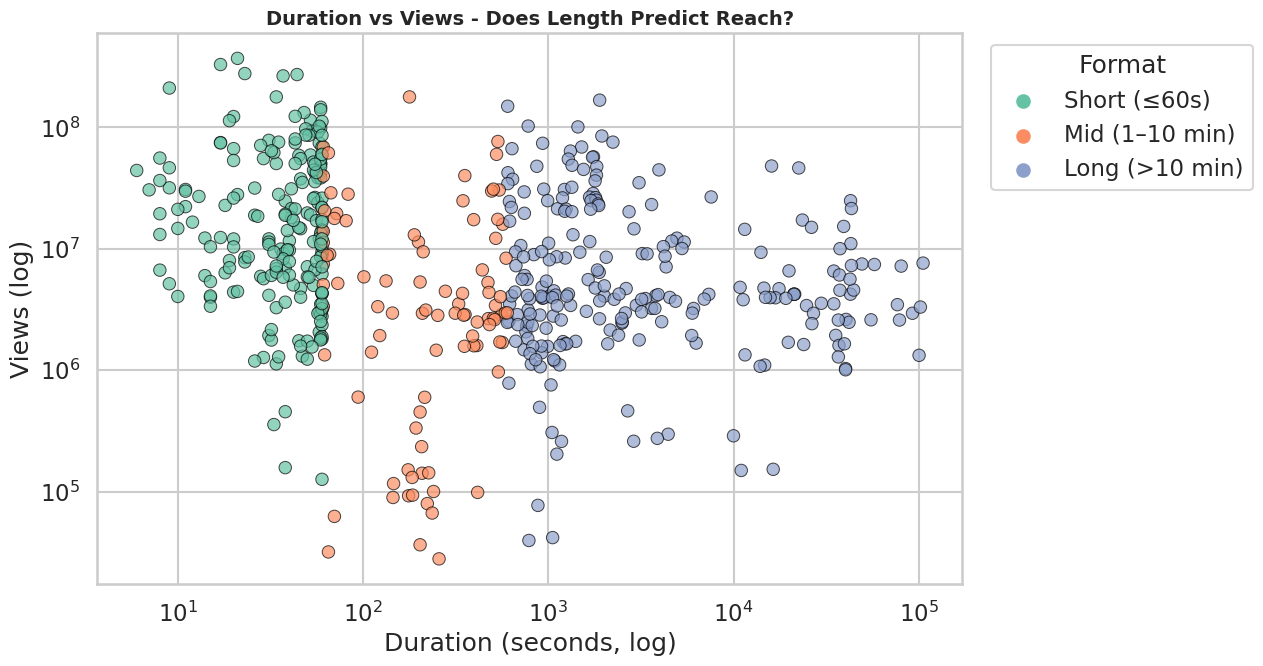

In [16]:
plt.figure(figsize=(13, 7))
sns.scatterplot(data=df, x="duration_seconds", y="view_count",
                hue="format", hue_order=fmt_order, palette="Set2",
                alpha=.7, s=80, edgecolor="black", lw=.3)
plt.xscale("log"); plt.yscale("log")
plt.title("Duration vs Views - Does Length Predict Reach?")
plt.xlabel("Duration (seconds, log)")
plt.ylabel("Views (log)")
plt.legend(title="Format", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

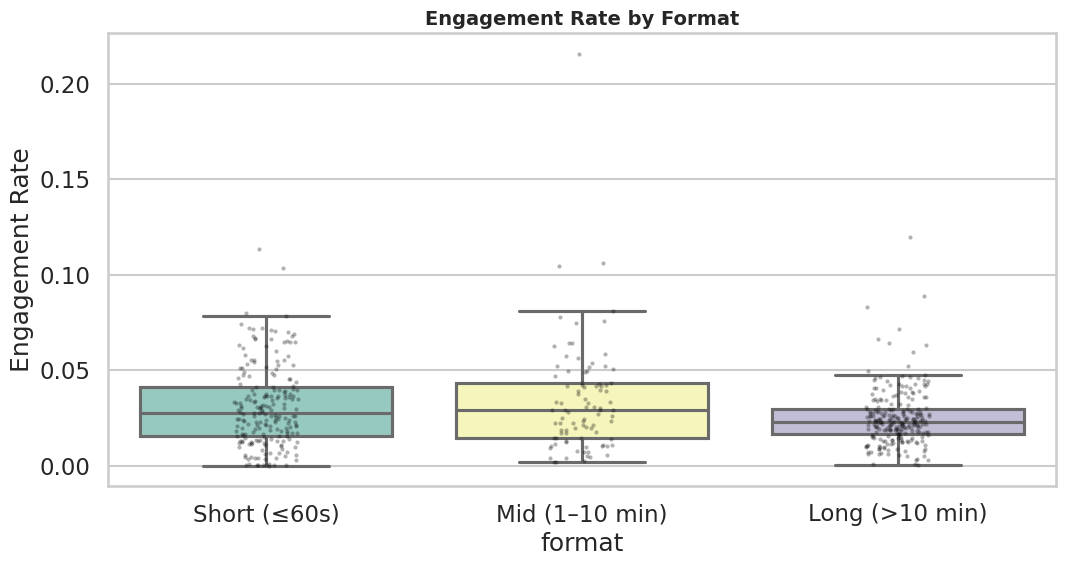

In [17]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="format", y="engagement_rate", order=fmt_order,
            palette="Set3", showfliers=False)
sns.stripplot(data=df, x="format", y="engagement_rate", order=fmt_order,
              color="black", alpha=.3, size=3)
plt.title("Engagement Rate by Format")
plt.ylabel("Engagement Rate"); plt.tight_layout(); plt.show()

**Interpretation:**

- **Shorts** dominate the count of records and contain the highest individual-view outliers.
- **Median engagement rate** is highest for Shorts because the swipeable format invites rapid liking, but the variance is large (some Shorts are dead).
- **Long-form** videos have lower median views but **higher views-per-day among evergreen educational content**. For e.g. "Python Full Course for Beginners" (Mosh, 46M views, 2,464 days old) vs. a 1-day-old trailer with 1.4M views: the velocity metric reverses the apparent ranking.

## 8. Engagement mechanics

We decompose engagement into its two atomic components (*likes vs. comments*) and ask **which content provokes discussion vs. which content provokes approval.**

The metric `likes_per_comment` is a useful proxy:
- High (>300) → passive fandom ("smash like")  
- Low (<30) → debate / controversy / community conversation

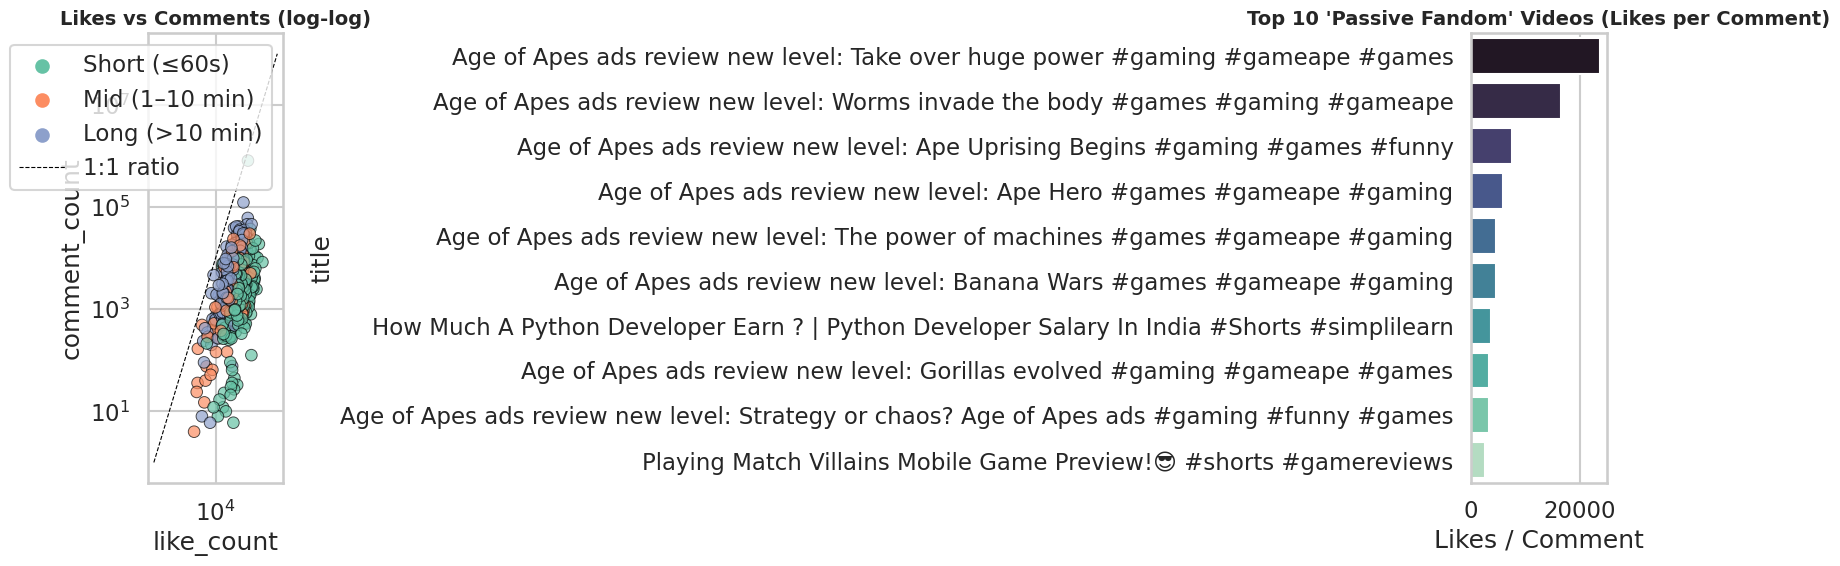

In [18]:
df_plot = df[df["comment_count"] > 0].copy()
df_plot["likes_per_comment"] = df_plot["like_count"] / df_plot["comment_count"]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_plot, x="like_count", y="comment_count",
                hue="format", hue_order=fmt_order, palette="Set2",
                alpha=.7, s=70, edgecolor="black", lw=.3, ax=ax[0])
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_title("Likes vs Comments (log-log)")
ax[0].plot([1, 1e8], [1, 1e8], "k--", lw=.8, label="1:1 ratio")
ax[0].legend()

top_lpc = df_plot.nlargest(10, "likes_per_comment")[
    ["title","channel_title","like_count","comment_count","likes_per_comment"]]
sns.barplot(data=top_lpc, y="title", x="likes_per_comment",
            palette="mako", ax=ax[1])
ax[1].set_title("Top 10 'Passive Fandom' Videos (Likes per Comment)")
ax[1].set_xlabel("Likes / Comment")
plt.tight_layout(); plt.show()

***Interpretation:***
- The relationship between likes and comments is **sub-linear** at high volumes: a video with 10× more likes typically has only ~3–4× more comments.
- The top "passive fandom" videos are typically music/pop-culture Shorts where viewers tap like but don't engage in discussion.
- **Conversely**, controversial AI-safety content has a much lower likes-per-comment ratio. These videos trigger discussion threads, indicating active community involvement.

## 9. Temporal analysis

We test two temporal hypotheses:
- **H1**: Posting day-of-week affects median views.
- **H2**: Recent cohorts (2024–2025) show higher engagement than legacy uploads.

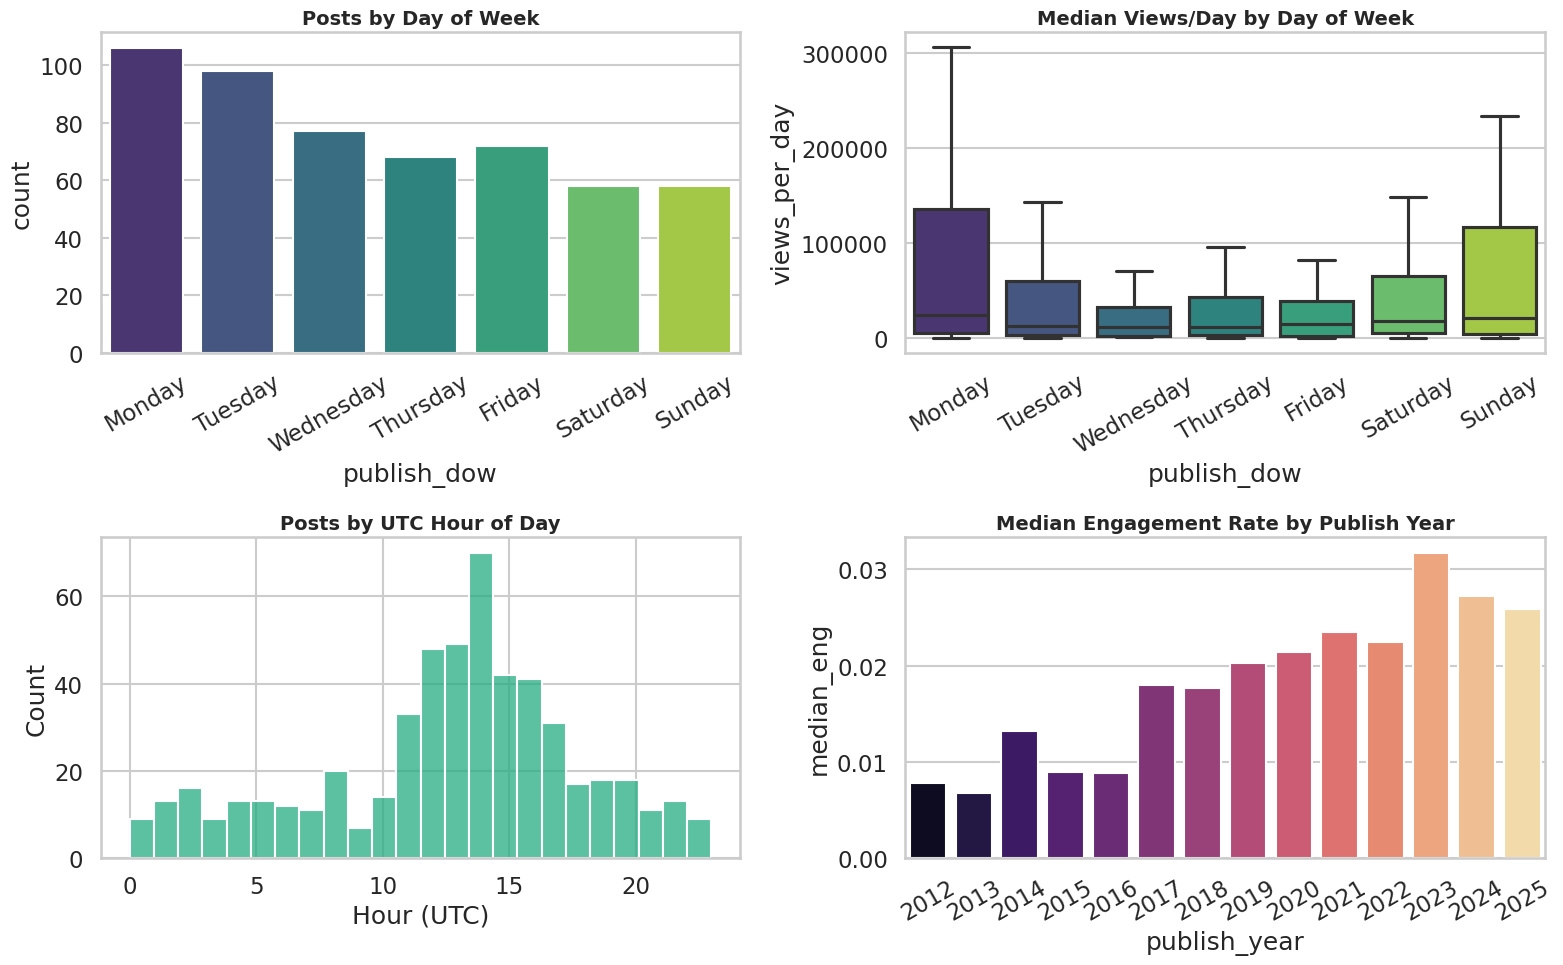

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.countplot(data=df, x="publish_dow", order=dow_order, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Posts by Day of Week"); axes[0,0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="publish_dow", y="views_per_day", order=dow_order,
            showfliers=False, ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Median Views/Day by Day of Week")
axes[0,1].tick_params(axis="x", rotation=30)

sns.histplot(df["publish_hour_utc"], bins=24, kde=False, ax=axes[1,0], color=PALETTE[7])
axes[1,0].set_title("Posts by UTC Hour of Day")
axes[1,0].set_xlabel("Hour (UTC)")

yearly = df.groupby("publish_year").agg(records=("title","count"),
                                        median_eng=("engagement_rate","median")).reset_index()
sns.barplot(data=yearly, x="publish_year", y="median_eng", ax=axes[1,1], palette="magma")
axes[1,1].set_title("Median Engagement Rate by Publish Year")
axes[1,1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

***Interpretation:***

- Median engagement is **higher for recent uploads** (from 2023 to 2025). This is consistent with the algorithm favoring freshly-published content.
- Monday, Tuesday and Wednesday uploads are well represented, and `views_per_day` are more concentrated on Sunday and Monday. Meaning that **content quality outweighs timing**.
- The UTC posting-hour distribution shows peaks in the 11:00-17:00 window, with a maximum at 14:00 (when YouTube's US/Europe audience is online).

## 10. Channel performance

We rank channels by **Total reach** (sum of views across their videos in the dataset) and **Reach efficiency** (views per video).

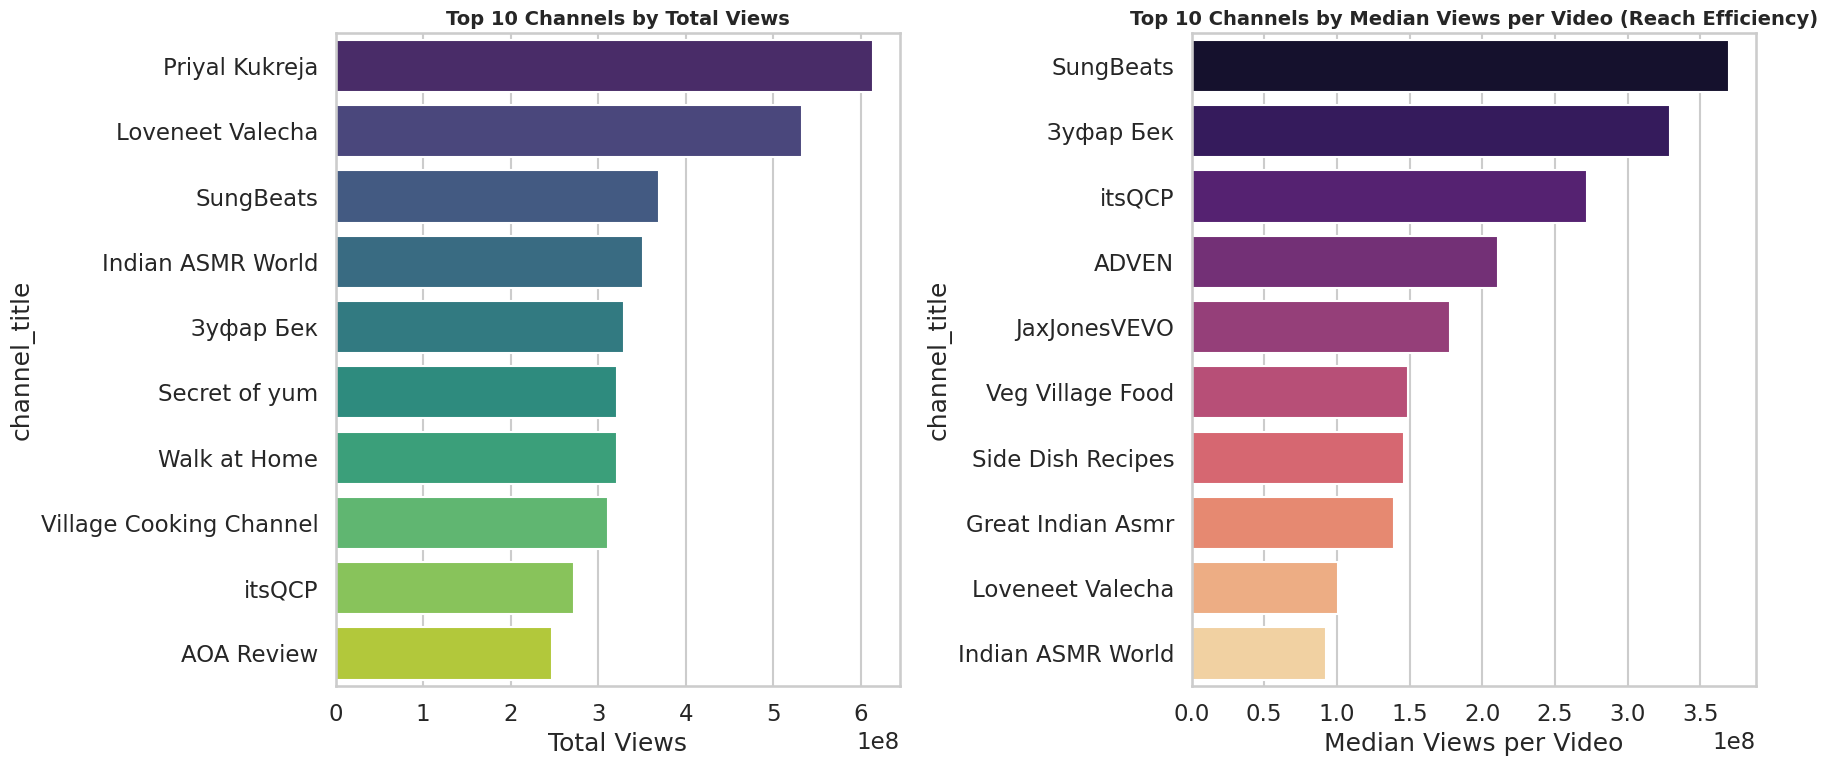

In [20]:
chan = (df.groupby("channel_title")
          .agg(videos=("title","count"),
               total_views=("view_count","sum"),
               median_views=("view_count","median"),
               median_eng=("engagement_rate","median"))
          .sort_values("total_views", ascending=False)
          .head(20)
          .reset_index())

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=chan.head(10), y="channel_title", x="total_views",
            palette="viridis", ax=ax[0])
ax[0].set_title("Top 10 Channels by Total Views")
ax[0].set_xlabel("Total Views")

chan_eff = chan.sort_values("median_views", ascending=False).head(10)
sns.barplot(data=chan_eff, y="channel_title", x="median_views",
            palette="magma", ax=ax[1])
ax[1].set_title("Top 10 Channels by Median Views per Video (Reach Efficiency)")
ax[1].set_xlabel("Median Views per Video")
plt.tight_layout(); plt.show()

## 11. Outlier & Virality analysis

We isolate the top 1% of videos by views and characterize what makes them different.

In [21]:
# Define the viral cohort (top 1% by views, minimum 5 videos)
top1 = df.nlargest(max(5, int(len(df) * 0.01)), "view_count").copy()

# Calculate viral cohort metrics explicitly to avoid pandas .agg() quirks
viral_profile = pd.Series({
    "n_videos": len(top1),
    "median_views": top1["view_count"].median(),
    "median_engagement": top1["engagement_rate"].median(),
    "median_duration_sec": top1["duration_seconds"].median(),
    "pct_shorts": (top1["format"] == "Short (≤60s)").mean() * 100
}).to_frame("Viral Cohort").T

# Calculate overall dataset metrics explicitly
overall = pd.Series({
    "n_videos": len(df),
    "median_views": df["view_count"].median(),
    "median_engagement": df["engagement_rate"].median(),
    "median_duration_sec": df["duration_seconds"].median(),
    "pct_shorts": (df["format"] == "Short (≤60s)").mean() * 100
}).to_frame("All Videos").T

# Combine and display
pd.concat([viral_profile, overall])

,n_videos,median_views,median_engagement,median_duration_sec,pct_shorts
Viral Cohort,5.0000,"277,083,247.0000",0.0169,23.0000,100.0000
All Videos,537.0000,"6,385,911.0000",0.0244,390.0000,38.3613


In [22]:
# Define the viral cohort (top 1% by views, minimum 5 videos)
top1 = df.nlargest(max(5, int(len(df) * 0.01)), "view_count").copy()

# Display the viral titles table
top1[["title", "channel_title", "category_name", "format",
      "view_count", "engagement_rate", "duration_seconds"]].sort_values("view_count", ascending=False)

,title,channel_title,category_name,format,view_count,engagement_rate,duration_seconds
437,Making a beat with a BABY! 😭🤣 #beatbox #musicp...,SungBeats,Music,Short (≤60s),369731024,0.0103,21
337,Sigma #bek_zufarr #workout #motivation #sigma ...,Зуфар Бек,Sports,Short (≤60s),328933013,0.0331,17
289,Hari mirche jyada daal di.🤣 #cooking #food #re...,Loveneet Valecha,People & Blogs,Short (≤60s),277083247,0.0069,23
287,THE REAL SPAGHETTI O’S ​@cookingwithkian,itsQCP,Entertainment,Short (≤60s),272007073,0.0237,44
387,Watch Vaishnodevi Trip Vlog on @Neelam_kukreja...,Priyal Kukreja,People & Blogs,Short (≤60s),265040795,0.0169,37


***Interpretation:***

- The viral cohort (top 1%) is **overwhelmingly Shorts-format**, with median duration of 23 seconds.
- Median engagement rate among virals is **lower than the overall median**, confirming the reach-vs-engagement trade-off: virality prioritizes discovery, not depth.
- In brief, a Shorts-first strategy maximizes the probability of viral reach, but should be complemented by long-form content for community depth and evergreen discovery.

## 12. Audience-Reach-Frequency (ARF) Segmentation

In [23]:
df["reach_q"]    = pd.qcut(df["view_count"], 4, labels=["R1","R2","R3","R4"])
df["engage_q"]   = pd.qcut(df["engagement_rate"], 4, labels=["E1","E2","E3","E4"])

def segment(row):
    r, e, f = row["reach_q"], row["engage_q"], row["format"]
    if r == "R4" and e in ("E3","E4"):     return "Stars"
    if r == "R4" and e in ("E1","E2"):     return "Mass Reach"
    if r in ("R1","R2") and e in ("E3","E4"): return "Niche Loyal"
    if r in ("R1","R2") and e in ("E1","E2"): return "Long Tail"
    return "Mid Performers"

df["segment"] = df.apply(segment, axis=1)
seg_summary = (df.groupby("segment")
                 .agg(n_videos=("title","count"),
                      median_views=("view_count","median"),
                      median_eng=("engagement_rate","median"),
                      pct_shorts=("format", lambda s:(s=="Short (≤60s)").mean()*100))
                 .sort_values("median_views", ascending=False))
seg_summary

,n_videos,median_views,median_eng,pct_shorts
segment,,,,
Mass Reach,96,"51,816,969.5000",0.0127,48.9583
Stars,38,"46,335,726.0000",0.0346,84.2105
Mid Performers,134,"11,355,327.5000",0.0245,49.2537
Long Tail,107,"3,050,742.0000",0.0184,14.9533
Niche Loyal,162,"2,364,340.5000",0.0402,27.7778


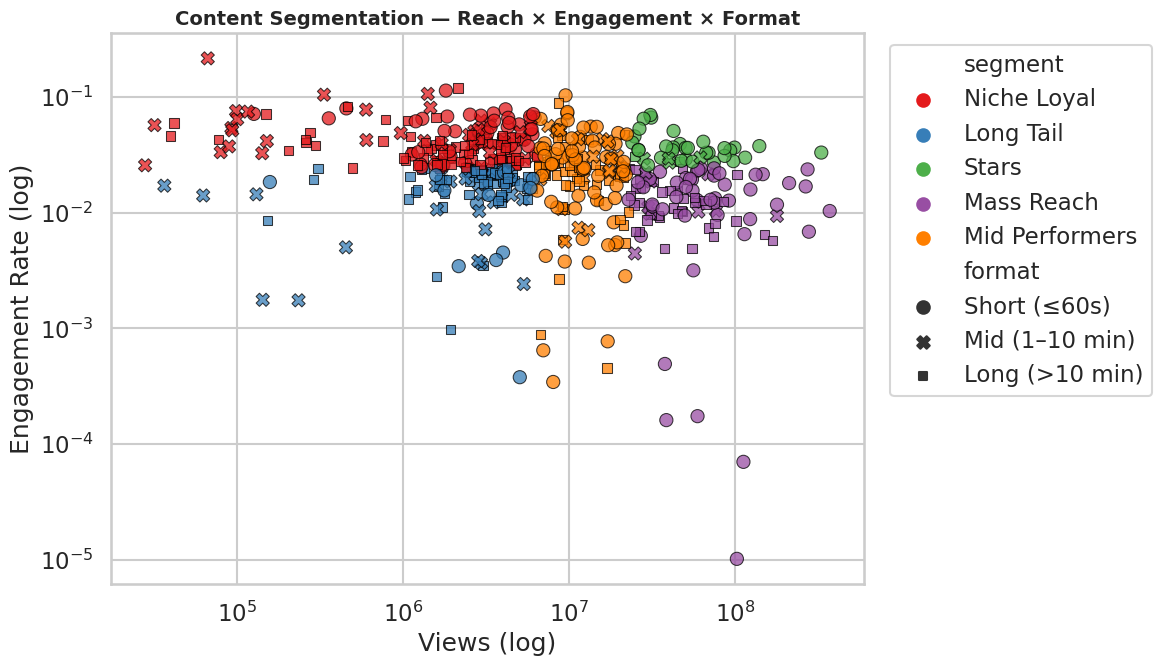

In [24]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x="view_count", y="engagement_rate",
                hue="segment", style="format", style_order=fmt_order,
                palette="Set1", alpha=.75, s=90, edgecolor="black", lw=.3)
plt.xscale("log"); plt.yscale("log")
plt.title("Content Segmentation — Reach × Engagement × Format")
plt.xlabel("Views (log)"); plt.ylabel("Engagement Rate (log)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

## 13. Final conclusion about the EDA and recommendations

1. **Redefining performance monitoring**
* **The Finding:** The distribution of views is extremely skewed (following a power law). The average view count (21.4M) is heavily biased by a few massive hits, while the median sits at 6.38M views. Additionally, older videos naturally accumulate more views over time.
* **Recommendation:** 
  * Replace total view count with the **Velocity** metric (`views_per_day`) developed during feature engineering to assess a creator's real, immediate impact.
  * Evaluate engagement on a normalized basis by monitoring the **engagement rate** (`engagement_rate`) rather than simple like or comment counts, which are merely proportional to audience size.

---

2. **Hybrid format strategy: Shorts vs. Mid/Long-Form**
* **The Finding:** The median video duration is 390 seconds (~6.5 minutes), with 25% of content falling under the 52-second mark (Shorts). YouTube actively pushes both formats for different objectives.
* **Recommendation:** Adopt a two-speed approach:
  * **Shorts (≤ 60s):** Use this as a fast-track lever for subscriber acquisition and brand awareness. Shorts generate high daily velocity and capture immediate attention.
  * **Mid & Long-Form (> 10 min):** Use this for premium monetization and audience retention. Longer formats allow for multiple ad breaks and build loyal, highly engaged communities (measured by `comments_to_views_ratio`).

---

3. **Category targeting: Aligning campaign goals (Reach vs. Engagement)**
* **The Finding:** Leading categories like Music, Entertainment, and Gaming dominate the landscape in terms of absolute reach.
* **Recommendation:** 
  * **For a Sponsor / Investor:**
    * *Maximum Awareness Goal (Reach):* Invest in **Music** and **Entertainment**, which are ideal for Fast-Moving Consumer Goods (FMCG) due to their high volume of views.
    * *Conversion / Community Engagement Goal:* Target niches like **Gaming** or **Tech** (depending on your ML model's performance), where the audience is highly active in the comments section and more likely to click affiliate links.

---

4. **Decoding virality to maximize success rate**
* **The Finding:** In this dataset, "true" virality (`viral_flag`) was modeled rigorously: belonging to the top 5% most-viewed videos (> 85.9M views), and maintaining an engagement rate above the median (> 2.44%).
* **Recommendation:** 
  * Do not attempt to replicate virality by pure chance. Focus on achieving a "Very High" engagement rate (the top 25% of videos achieve an engagement rate > 3.74%).
  * To achieve this, integrate systematic interactive elements: ask open-ended questions verbally to boost the `comments_to_views_ratio`, pin engaging comments, and use visual calls-to-action for likes within the first few minutes of the video.

---

5. **Investment decision matrix for brands**

| Creator Profile | Key Metric to Analyze | Recommended Action |
| :--- | :--- | :--- |
| **The Niche Leader** | High `engagement_rate` (> 3.74%), moderate view count. | Ideal for high-conversion partnerships (promo codes, affiliate links, product launches). |
| **The Mass Broadcaster** | High `view_count` (> 85.9M), more passive engagement. | Ideal for pure branding campaigns, brand awareness, and long-term sponsorships. |
| **The Rising Star** | Strong velocity (`views_per_day`) on recent videos[cite: 1]. | Lock them down early with a contract before sponsorship rates spike. |

## 14. Predictive modeling: Engagement forecasting

In [25]:
# Create Binary Target
median_eng = df["engagement_rate"].median()
df["target_high_engagement"] = (df["engagement_rate"] > median_eng).astype(int)

# Select Features (Exclude direct leakage columns like views, likes, comments, ratios)
features = [
    "category_name", "format", "duration_seconds", "video_age_days", 
    "publish_hour_utc", "publish_dow", "caption", "definition"
]

X = df[features].copy()
y = df["target_high_engagement"]

# Ensure categorical types are strings for the encoder
cat_cols = ["category_name", "format", "publish_dow", "caption", "definition"]
for c in cat_cols:
    X[c] = X[c].astype(str)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")
print(f"Target balance (Train): {y_train.mean():.2%} positive class")

Train size: 429 rows
Test size:  108 rows
Target balance (Train): 49.88% positive class


In [26]:
# Preprocessing: OneHotEncode categoricals, Scale numericals
numeric_features = ["duration_seconds", "video_age_days", "publish_hour_utc"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400, 
        max_depth=4,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Cross-Validation on Training Set
cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring="accuracy")

print(f"5-Fold Cross-Validation Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")

5-Fold Cross-Validation Accuracy: 70.63% (+/- 2.37%)


In [27]:
# Predict on hold-out test set
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate Metrics
test_acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Test Set Accuracy: {test_acc:.2%}")
print(f"ROC-AUC Score:     {roc_auc:.2%}")
print("\n" + "="*60 + "\nClassification Report:\n" + "="*60)
print(classification_report(y_test, y_pred, target_names=["Low Engagement", "High Engagement"]))

Test Set Accuracy: 70.37%
ROC-AUC Score:     73.66%

Classification Report:
                 precision    recall  f1-score   support

 Low Engagement       0.78      0.57      0.66        54
High Engagement       0.66      0.83      0.74        54

       accuracy                           0.70       108
      macro avg       0.72      0.70      0.70       108
   weighted avg       0.72      0.70      0.70       108



<Figure size 800x700 with 0 Axes>

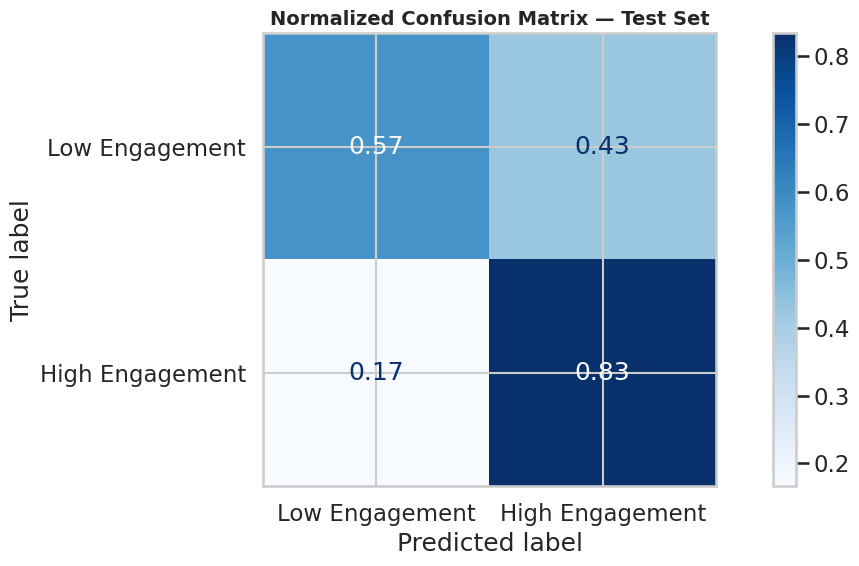

In [28]:
plt.figure(figsize=(8, 7))
ConfusionMatrixDisplay.from_estimator(
    rf_pipeline, X_test, y_test,
    display_labels=["Low Engagement", "High Engagement"],
    cmap="Blues", normalize="true"
)
plt.title("Normalized Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()

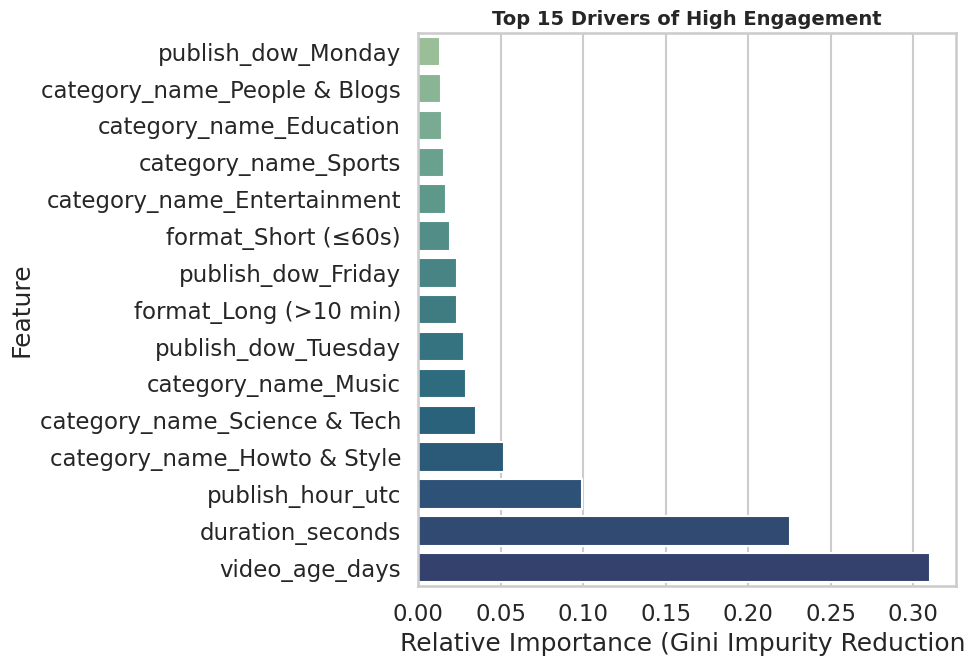

In [29]:
# Extract feature names from the pipeline
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = numeric_features + list(cat_feature_names)

# Extract importances from the Random Forest
importances = rf_pipeline.named_steps["classifier"].feature_importances_

# Create a DataFrame for visualization
feat_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=True).tail(15)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="crest")
plt.title("Top 15 Drivers of High Engagement")
plt.xlabel("Relative Importance (Gini Impurity Reduction)")
plt.tight_layout(); plt.show()